# Assignment: Linear Regression
**Salary Prediction using Simple Linear Regression**

## 0. Background

- **AI (Artificial Intelligence):** Simulation of human intelligence by machines — enabling reasoning, learning, and decision-making.
- **ML (Machine Learning):** A subset of AI where algorithms learn patterns from data to make predictions without being explicitly programmed.
- **DL (Deep Learning):** A subset of ML using multi-layered neural networks capable of learning complex representations from raw data.
- **Data Science:** An interdisciplinary field combining statistics, programming, and domain knowledge to extract actionable insights from data.

In this assignment, we apply **supervised ML** — specifically **regression** — to predict a continuous output (Salary) from input features (Years of Experience).

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')


## TASK 1: Simple Linear Regression (YearsExperience → Salary)

## 1. Data Retrieval and Collection

In [2]:

df = pd.read_csv('Salary_Data.csv')

print('Shape:', df.shape)
print('\nColumn Names:', df.columns.tolist())
print('\nFirst 5 rows:')
df.head()

Shape: (30, 2)

Column Names: ['YearsExperience', 'Salary']

First 5 rows:


,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [3]:
# Dataset overview
print('Dataset Info:')
df.info()
print('\nStatistical Summary:')
df.describe()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 612.0 bytes

Statistical Summary:


,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


**Description:** The Salary dataset contains two columns — `YearsExperience` (years of work experience) and `Salary` (annual salary in dollars). It is a small, clean dataset commonly used to demonstrate simple linear regression. The goal is to predict `Salary` based on `YearsExperience`.

## 2. Data Cleaning

In [4]:
# Check for missing values
print('Missing values per column:')
print(df.isnull().sum())

# Check data types
print('\nData types:')
print(df.dtypes)

# Check for duplicates
print('\nDuplicate rows:', df.duplicated().sum())

Missing values per column:
YearsExperience    0
Salary             0
dtype: int64

Data types:
YearsExperience    float64
Salary               int64
dtype: object

Duplicate rows: 0


In [5]:
# Handle missing values (if any)
if df.isnull().sum().sum() > 0:
    df.dropna(inplace=True)
    print('Missing values dropped. New shape:', df.shape)
else:
    print('No missing values found. Dataset is clean.')

# Remove duplicates if any
df.drop_duplicates(inplace=True)
print('Final dataset shape:', df.shape)

No missing values found. Dataset is clean.
Final dataset shape: (30, 2)


**Summary:** The Salary dataset is already clean with no missing values or invalid entries. Both columns are numeric (float64), making them directly usable for linear regression without any encoding or imputation.

## 3. Feature Design

In [6]:
# Separate feature (X) and label (y)
X = df[['YearsExperience']]   # 2D array required by sklearn
y = df['Salary']

print('Feature shape (X):', X.shape)
print('Label shape (y):', y.shape)
print('\nFeature preview:')
print(X.head())

Feature shape (X): (30, 1)
Label shape (y): (30,)

Feature preview:
   YearsExperience
0              1.1
1              1.3
2              1.5
3              2.0
4              2.2


**Feature Design Explanation:**
- **Input Feature (X):** `YearsExperience` — a continuous numeric variable. More experience generally correlates with higher pay, making it a strong predictor.
- **Label (y):** `Salary` — the continuous target variable we want to predict.
- No feature engineering or scaling is strictly required for simple linear regression, but we keep `X` as a 2D array for sklearn compatibility.

## 4. Algorithm Selection

**Why Linear Regression?**

Linear Regression models the relationship between input feature(s) and a **continuous output** as a straight line:

ŷ = w·x + b

where `w` is the slope (coefficient) and `b` is the intercept.

It is appropriate here because:
- The target variable `Salary` is **continuous** (not categorical).
- There is an expected **linear relationship** between years of experience and salary.
- The dataset is small and clean — a simple model is sufficient and interpretable.
- Linear Regression is computationally efficient with a closed-form solution (Normal Equation).

## 5. Loss Function Selection

**Mean Squared Error (MSE):**

MSE = (1/n) · Σ(yᵢ - ŷᵢ)²

- MSE measures the **average squared difference** between actual and predicted values.
- Squaring penalizes **large errors more heavily**, making the model sensitive to outliers.
- During training, the algorithm minimizes MSE to find the optimal `w` and `b`.
- MSE is always non-negative; a value of 0 means perfect predictions.

## 6. Model Learning (Training)

In [10]:
# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Training samples:', X_train.shape[0])
print('Testing samples :', X_test.shape[0])

# Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

print('\n Learned Parameters ')
print(f'Coefficient (slope)  : {model.coef_[0]:,.2f}')
print(f'Intercept            : {model.intercept_:,.2f}')

Training samples: 24
Testing samples : 6

 Learned Parameters 
Coefficient (slope)  : 9,423.82
Intercept            : 25,321.58


**How parameters are learned:**
Linear Regression finds the optimal `w` (slope) and `b` (intercept) using the **Normal Equation** or **Gradient Descent** to minimize MSE:

1. **Normal Equation:** w = (XᵀX)⁻¹ Xᵀy — gives an exact closed-form solution.
2. **Gradient Descent:** Iteratively updates parameters in the direction that reduces the loss.
sklearn uses the Normal Equation (via SVD) by default for small datasets.

**Interpretation of Parameters:**
1. **Coefficient (slope):** For every additional year of experience, the salary increases by approximately this amount (in dollars).
2. **Intercept:** The predicted salary when `YearsExperience = 0` (i.e., entry-level baseline salary).

## 7. Model Evaluation

In [8]:
# Predictions
y_pred = model.predict(X_test)

# Metrics
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print('=== Model Evaluation ===')
print(f'Mean Squared Error  (MSE) : {mse:,.2f}')
print(f'Root Mean Sq. Error (RMSE): {rmse:,.2f}')
print(f'Mean Absolute Error (MAE) : {mae:,.2f}')
print(f'R² Score                  : {r2:.4f}')

=== Model Evaluation ===
Mean Squared Error  (MSE) : 49,830,096.86
Root Mean Sq. Error (RMSE): 7,059.04
Mean Absolute Error (MAE) : 6,286.45
R² Score                  : 0.9024


**Interpretation:**
1. **MSE / RMSE:** RMSE is in the same unit as Salary (dollars), representing the average prediction error.
2. **R² Score:** Indicates the proportion of variance in Salary explained by YearsExperience. A value close to 1.0 means the model fits the data well.

## Visualization

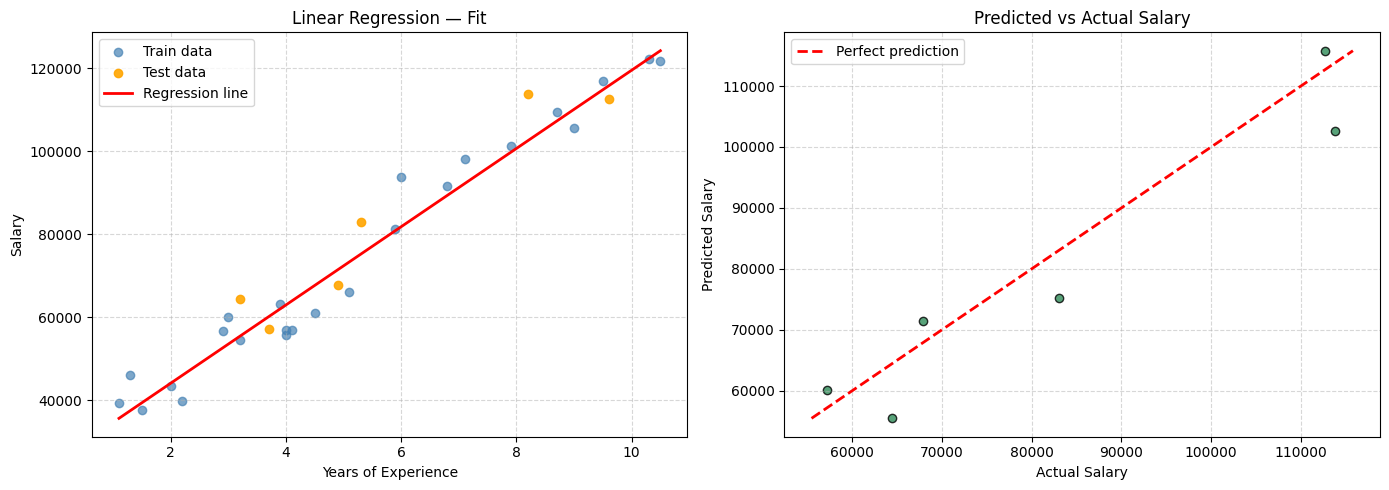

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Regression line
axes[0].scatter(X_train, y_train, color='steelblue', alpha=0.7, label='Train data')
axes[0].scatter(X_test,  y_test,  color='orange',    alpha=0.9, label='Test data')
x_line = np.linspace(X.min().values[0], X.max().values[0], 100).reshape(-1, 1)
axes[0].plot(x_line, model.predict(x_line), color='red', linewidth=2, label='Regression line')
axes[0].set_xlabel('Years of Experience')
axes[0].set_ylabel('Salary')
axes[0].set_title('Linear Regression — Fit')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot 2: Predicted vs Actual
axes[1].scatter(y_test, y_pred, color='seagreen', alpha=0.8, edgecolors='black')
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect prediction')
axes[1].set_xlabel('Actual Salary')
axes[1].set_ylabel('Predicted Salary')
axes[1].set_title('Predicted vs Actual Salary')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Discussion

The simple linear regression model performs good on the dataset because there is a strong,almost linear relationship between years of experience and salary. The high R^2 score confirms that YearsExperience alone explains most of the variance in Salary.

The model uses only one feature. In reality, salary depends on many factors.Linear regression cannot capture non-linear relationships.The dataset is very small which may not generalize well to unseen data.

## Conclusion

This assignment demonstrated the complete ML pipeline applied to a regression problem from data retrival to cleaning to model selection and training and evaluation.

The regression line and predicted vs actual plots visually confirm a good fit.For more accurate real-world predictions,additional features should be incorporated using Multiple Linear Regression.